In [3]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import matplotlib.pyplot as plt
from scripts.constants import *
from scripts.hamiltonian import *

In [4]:
t = 1
gap_p = cp.array([0.1j, 0.0j]) * t
lattice = Lattice(10,10,pbc_x=False,pbc_y=False)
block = cp.zeros((4,4), dtype=cp.complex128)
for i, j in lattice.edges:
    block[:,:]=0
    block[0:2, 0:2] = -t * s0
    block[2:4, 2:4] = t * s0

    gap_ij = unconventional_gap(lattice.get_disp(i,j),gap_p = gap_p)
    block[0:2, 2:4] = gap_ij
    block[2:4, 0:2] = -gap_ij.T.conj()


In [5]:
print(lattice.edges)

[(0, 1), (0, 10), (1, 2), (1, 0), (1, 11), (2, 3), (2, 1), (2, 12), (3, 4), (3, 2), (3, 13), (4, 5), (4, 3), (4, 14), (5, 6), (5, 4), (5, 15), (6, 7), (6, 5), (6, 16), (7, 8), (7, 6), (7, 17), (8, 9), (8, 7), (8, 18), (9, 8), (9, 19), (10, 11), (10, 20), (10, 0), (11, 12), (11, 10), (11, 21), (11, 1), (12, 13), (12, 11), (12, 22), (12, 2), (13, 14), (13, 12), (13, 23), (13, 3), (14, 15), (14, 13), (14, 24), (14, 4), (15, 16), (15, 14), (15, 25), (15, 5), (16, 17), (16, 15), (16, 26), (16, 6), (17, 18), (17, 16), (17, 27), (17, 7), (18, 19), (18, 17), (18, 28), (18, 8), (19, 18), (19, 29), (19, 9), (20, 21), (20, 30), (20, 10), (21, 22), (21, 20), (21, 31), (21, 11), (22, 23), (22, 21), (22, 32), (22, 12), (23, 24), (23, 22), (23, 33), (23, 13), (24, 25), (24, 23), (24, 34), (24, 14), (25, 26), (25, 24), (25, 35), (25, 15), (26, 27), (26, 25), (26, 36), (26, 16), (27, 28), (27, 26), (27, 37), (27, 17), (28, 29), (28, 27), (28, 38), (28, 18), (29, 28), (29, 39), (29, 19), (30, 31), (30, 

In [10]:
block[:,:]=0
block[0:2, 0:2] = -t * s0
block[2:4, 2:4] = t * s0

gap_ij = unconventional_gap(lattice.get_disp(0,1),gap_d = 0.2, gap_p=gap_p)
block[0:2, 2:4] = gap_ij
block[2:4, 0:2] = -gap_ij.T.conj()
print(block)


[[-1. +0.j  -0. +0.j   0. +0.j   0.2-0.1j]
 [-0. +0.j  -1. +0.j  -0.2-0.1j  0. +0.j ]
 [-0. +0.j   0.2-0.1j  1. +0.j   0. +0.j ]
 [-0.2-0.1j -0. +0.j   0. +0.j   1. +0.j ]]


In [11]:
print(cp.allclose(block, block.conj().T, rtol=1e-6, atol=1e-6))


False


In [8]:
block[:,:]=0
block[0:2, 0:2] = -t * s0
block[2:4, 2:4] = t * s0

gap_ij = unconventional_gap(lattice.get_disp(0,1),gap_d = 0.2,gap_p = gap_p)
block[0:2, 2:4] = gap_ij
gap_ji = unconventional_gap(lattice.get_disp(1,0),gap_d = 0.2,gap_p = gap_p)
block[2:4, 0:2] = gap_ji

print(block)

[[-1. +0.j  -0. +0.j   0. +0.j   0.2-0.1j]
 [-0. +0.j  -1. +0.j  -0.2-0.1j  0. +0.j ]
 [ 0. +0.j   0.2+0.1j  1. +0.j   0. +0.j ]
 [-0.2+0.1j  0. +0.j   0. +0.j   1. +0.j ]]


In [9]:
print(cp.allclose(block, block.conj().T, rtol=1e-6, atol=1e-6))

False


In [14]:
block[:,:]=0
block[0:2, 0:2] = -t * s0
block[2:4, 2:4] = t * s0

gap_ij = unconventional_gap(lattice.get_disp(0,10),gap_d = 0.2, gap_p=gap_p)
block[0:2, 2:4] = gap_ij
block[2:4, 0:2] = -gap_ij.T.conj()
print(block)

[[-1. +0.j -0. +0.j  0. +0.j -0.2+0.j]
 [-0. +0.j -1. +0.j  0.2+0.j  0. +0.j]
 [-0. +0.j -0.2+0.j  1. +0.j  0. +0.j]
 [ 0.2+0.j -0. +0.j  0. +0.j  1. +0.j]]


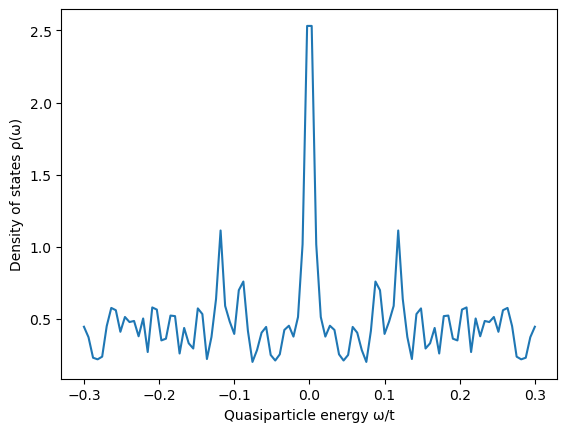

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from bodge import *

# Model parameters
Lx = 50
Ly = 50

t = 1
μ = -3 * t
Δp = 0.3 * t

# Construct the Hamiltonian
lattice = CubicLattice((Lx, Ly, 1))
system = Hamiltonian(lattice)

Δd = 0.1 * t
with system as (H, Δ):
    for i, j in lattice.bonds():
        H[i, j] = -t * σ0
    for i, j in lattice.bonds(axis=0):
        Δ[i, j] = -Δd * jσ2
    for i, j in lattice.bonds(axis=1):
        Δ[i, j] = -Δd * jσ2

# Calculate the density of states
i = (Lx//2, Ly//2, 0)
ω = np.linspace(-3 * Δd, 3 * Δd, 100)
ρ = system.ldos(i, ω)

# Plot the results
plt.figure()
plt.xlabel("Quasiparticle energy ω/t")
plt.ylabel("Density of states ρ(ω)")
plt.plot(ω, ρ)